In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#functions
def rk4(f, x, y, k, h):
    k1 = h*f(x, y, k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk4(f, xlim, yini, k, N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N, len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

def secant(ks, f, method, ybound, tol, maxiter):
    k1, k2 = ks
    iter = 0
    while abs(method(k2, f, ybound)) > tol and iter < maxiter:
        f1 = method(k1, f, ybound)
        f2 = method(k2, f, ybound)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
    return iter, k2

def simp13(y, h):
    store = y[0]**2 + y[-1]**2
    for i in range(1, len(y)-1):
        if i % 2 == 0:
            store += 2*y[i]**2
        else:
            store += 4*y[i]**2
    return np.sqrt(store * h / 3)

In [3]:
#Q1 a)

Vo = 40.0
Lo = 1.0

def pot_a(x):
    if abs(x) > Lo:
        return 0.0
    else:
        return -Vo*(1 - x**3)/2

def odefun_a(x, y, E):
    k2 = E - pot_a(x)
    return np.array([y[1], -k2 * y[0]])

def score_a(E, f, ybound):
    xlim = (-3.0, 3.0)
    N = 129
    yini1 = (ybound[0], 1e-2)
    xs1, ys1 = caller_rk4(odefun_a, xlim, yini1, E, N)
    a = abs(xs1 + Lo)
    n1 = np.where(a == np.min(a))[0][0]
    yini2 = (ybound[1], 1e-2)
    xs2, ys2 = caller_rk4(odefun_a, xlim[::-1], yini2, E, N)
    a = abs(xs2 + Lo)
    n2 = np.where(a == np.min(a))[0][0]
    ys2 = ys1[n1][0]*ys2/ys2[n2][0]
    return ys1[n1][1] - ys2[n2][1]

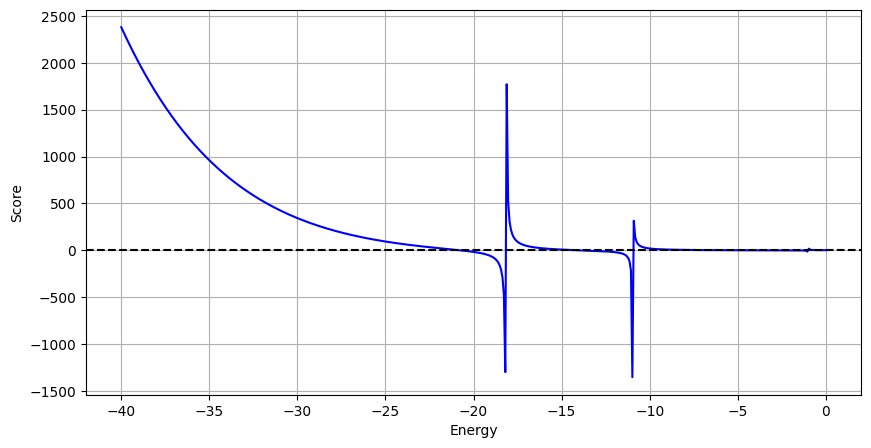

In [4]:
xlim_a = (-3.0, 3.0)
ybound_a = (0.0, 0.0)

Es_test = np.linspace(-Vo, 0, 500)
scores_a = [score_a(E, odefun_a, ybound_a) for E in Es_test]

plt.figure(figsize=(10, 5))
plt.plot(Es_test, scores_a, 'b-')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Energy')
plt.ylabel('Score')
plt.grid()
plt.show()

Eigenvalues: [-20.804649960453762, -20.804649815424277, -20.804649746964373, -5.099755191047941]


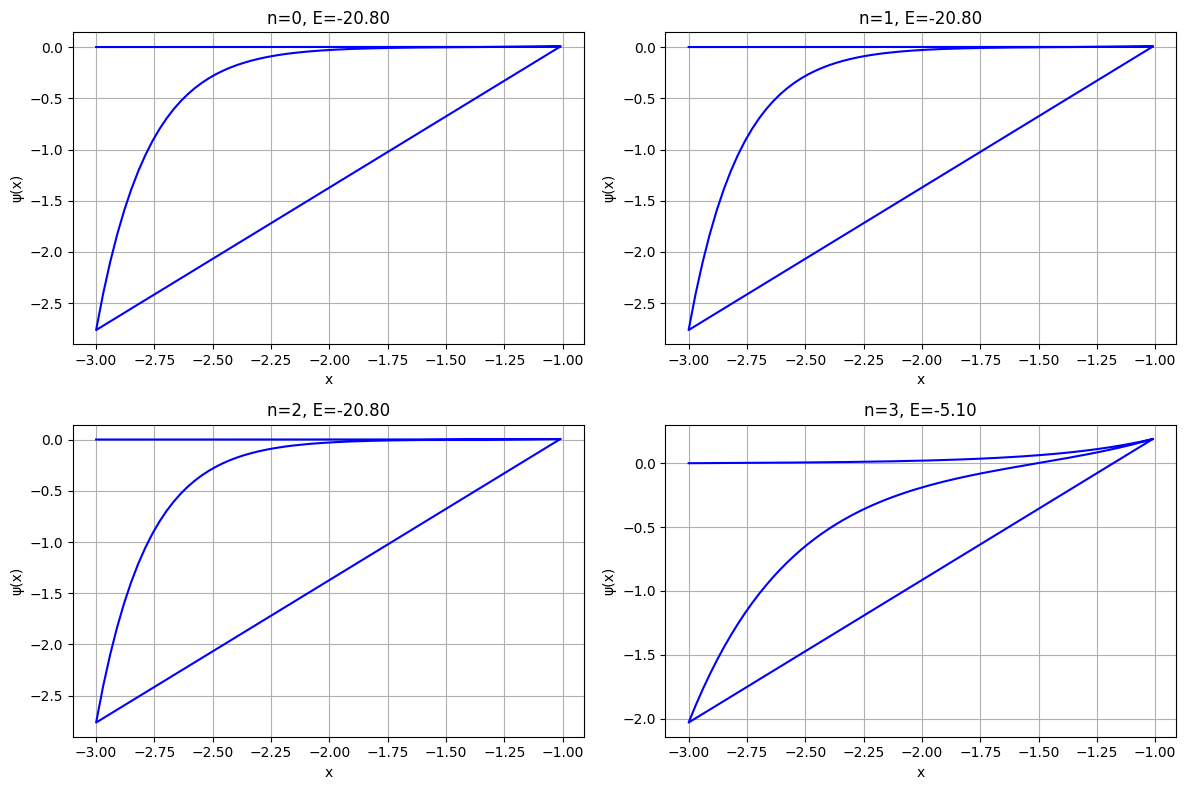

In [5]:
eigenvalues_a = []
eigenfunctions_a = []
E_ranges = [(-38, -36), (-30, -28), (-20, -18), (-12, -10)]

for E_ini in E_ranges:
    try:
        iter, E_eigen = secant(E_ini, odefun_a, score_a, ybound_a, 1e-5, 50)
        if E_eigen is not None:
            eigenvalues_a.append(E_eigen)
            yini1 = (ybound_a[0], 1e-2)
            xs1, ys1 = caller_rk4(odefun_a, xlim_a, yini1, E_eigen, 200)
            a = abs(xs1 + Lo)
            n1 = np.where(a == np.min(a))[0][0]
            yini2 = (ybound_a[1], 1e-2)
            xs2, ys2 = caller_rk4(odefun_a, xlim_a[::-1], yini2, E_eigen, 200)
            a = abs(xs2 + Lo)
            n2 = np.where(a == np.min(a))[0][0]
            ys2 = ys1[n1][0]*ys2/ys2[n2][0]
            psi = np.concatenate([ys1[:n1+1, 0], ys2[::-1][:len(xs2)-n2, 0]])
            xs_full = np.concatenate([xs1[:n1+1], xs2[::-1][:len(xs2)-n2]])
            h = xs_full[1] - xs_full[0]
            norm = simp13(psi, h)
            psi = psi / norm
            eigenfunctions_a.append((xs_full, psi))
    except:
        pass

print(f"Eigenvalues: {eigenvalues_a}")

plt.figure(figsize=(12, 8))
for i, (xs, psi) in enumerate(eigenfunctions_a):
    plt.subplot(2, 2, i+1)
    plt.plot(xs, psi, 'b-', linewidth=1.5)
    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title(f'n={i}, E={eigenvalues_a[i]:.2f}')
    plt.grid()
plt.tight_layout()
plt.show()

In [6]:
#Q1 b)
def pot_b(x):
    return x**2

def odefun_b(x, y, E):
    k2 = E - pot_b(x)
    return np.array([y[1], -k2 * y[0]])

def score_b(E, f, ybound):
    xlim = (-5.0, 5.0)
    N = 129
    yini = (ybound[0], 1e-2)
    xs, ys = caller_rk4(odefun_b, xlim, yini, E, N)
    return ys[-1][0] - ybound[1]

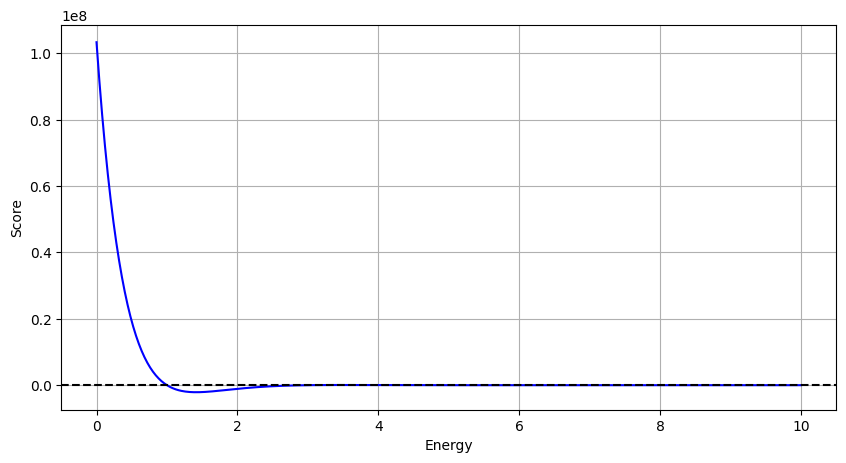

In [8]:
xlim_b = (-5.0, 5.0)
ybound_b = (0.0, 0.0)

Es_test = np.linspace(0, 10, 500)
scores_b = [score_b(E, odefun_b, ybound_b) for E in Es_test]

plt.figure(figsize=(10, 5))
plt.plot(Es_test, scores_b, 'b-')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Energy')
plt.ylabel('Score')
plt.grid()
plt.show()

Eigenvalues: [1.0000003864300337, 3.000005783816661, 5.0000251207068365, 7.000069389963982]
Theoretical: 1, 3, 5, 7, ...


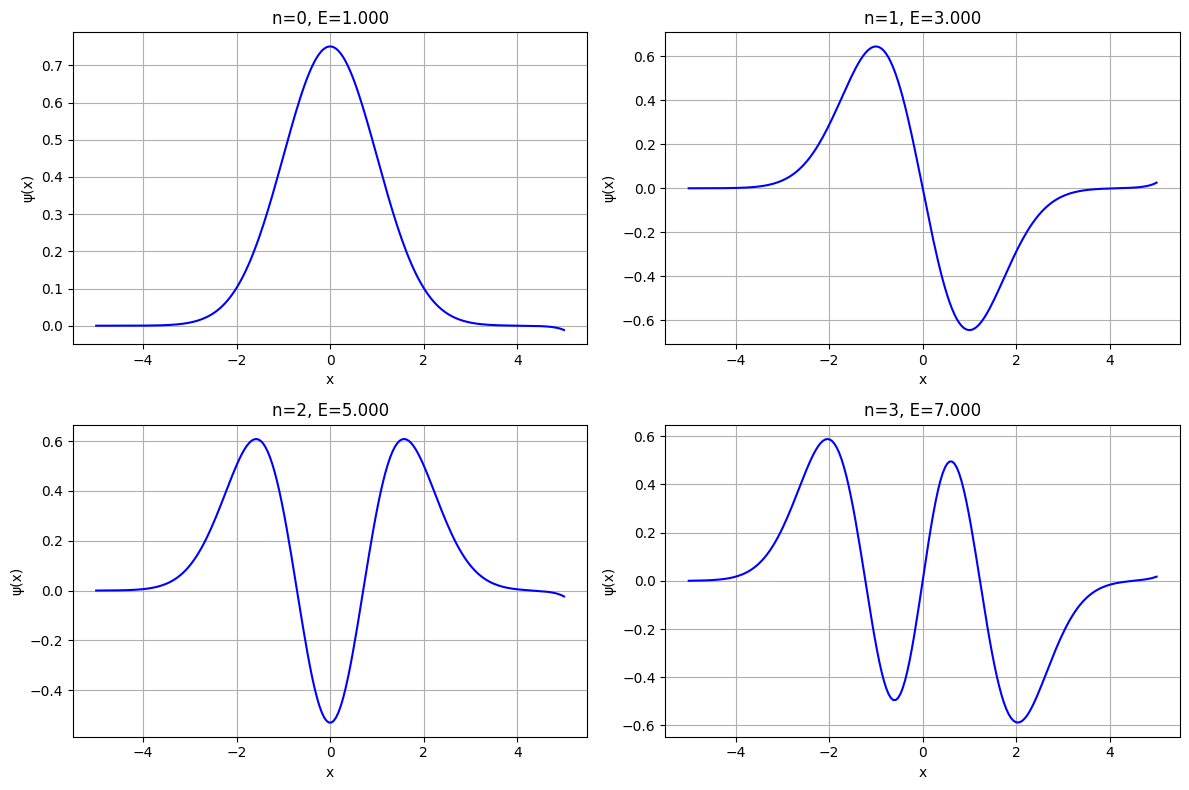

In [9]:
eigenvalues_b = []
eigenfunctions_b = []
E_ranges_b = [(0.8, 1.2), (2.8, 3.2), (4.8, 5.2), (6.8, 7.2)]

for E_ini in E_ranges_b:
    try:
        iter, E_eigen = secant(E_ini, odefun_b, score_b, ybound_b, 1e-5, 50)
        if E_eigen is not None:
            eigenvalues_b.append(E_eigen)
            yini = (ybound_b[0], 1e-2)
            xs, ys = caller_rk4(odefun_b, xlim_b, yini, E_eigen, 200)
            psi = ys[:, 0]
            h = xs[1] - xs[0]
            norm = simp13(psi, h)
            psi = psi / norm
            eigenfunctions_b.append((xs, psi))
    except:
        pass

print(f"Eigenvalues: {eigenvalues_b}")
print("Theoretical: 1, 3, 5, 7, ...")

plt.figure(figsize=(12, 8))
for i, (xs, psi) in enumerate(eigenfunctions_b):
    plt.subplot(2, 2, i+1)
    plt.plot(xs, psi, 'b-', linewidth=1.5)
    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title(f'n={i}, E={eigenvalues_b[i]:.3f}')
    plt.grid()
plt.tight_layout()
plt.show()